# 실전 프로젝트: 고객센터(CS) 자동화 에이전트 구축 🔥

## 1. 프로젝트 목표
앞선 01~03 챕터에서 배운 **Routing(분기)**, **Reflection(자가 검토)**, **Human-in-the-loop(사람 개입)** 3가지 LangGraph 핵심 패턴을 모두 결합하여, 실제 기업에서 도입할 법한 "고객 클레임 대응 봇"을 완성합니다.

## 2. 시나리오 및 파이프라인 (아키텍처)
1. **라우팅 (Router)**: 고객의 문의 내용을 분석하여 일반 문의면 즉시 답변하고, '불만/환불' 클레임이면 **사과문 작성 노드**로 보냅니다.
2. **반성 루프 (Reflection)**: 사과문 초안을 작성한 뒤, 스스로 "감정이 상한 고객에게 충분히 정중한가? 변명만 늘어놓지 않았는가?"를 평가합니다. 불합격 시 다시 작성합니다.
3. **승인 대기 (Human-in-the-loop)**: 품질 검증을 통과한 완벽한 사과문이라 하더라도, 발송 직전에 멈춰서 CS 담당자(사람)의 최종 승인을 기다립니다.

## 3. 라이브러리 import

In [1]:
import os
from dotenv import load_dotenv
from typing import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

## 4. State(상태) 정의

In [2]:
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

# 복합적인 파이프라인이므로 상태 가방에 많은 데이터가 들어갑니다.
class CSState(TypedDict):
    customer_msg: str      # 고객의 원본 메시지
    category: str          # 라우터가 판단한 카테고리 ('general' or 'claim')
    draft_response: str    # 봇이 작성한 답변 초안
    critique: str          # Reflection 평가 결과 (수정 사항)
    is_polite: bool        # Reflection 통과 여부
    revision_count: int    # 재작성 횟수

## 5. Node(노드) 정의
1) Router, 2) General Answer, 3) Claim Drafter, 4) Claim Evaluator, 5) Send

In [3]:
def node_router(state: CSState):
    print("\n🔍 [Router] 고객 문의를 분석합니다...")
    
    class Route(BaseModel):
        category: str = Field(description="불만, 화남, 환불 요청 등 클레임이면 'claim', 단순 정보나 인사면 'general'")
        
    router_llm = llm.with_structured_output(Route)
    res = router_llm.invoke([
        SystemMessage(content="당신은 10년차 CS 팀장입니다. 고객의 감정과 목적을 분석해 분류하세요."),
        HumanMessage(content=state["customer_msg"])
    ])
    
    print(f"-> 분류 결과: {res.category.upper()}")
    return {"category": res.category}

def node_general(state: CSState):
    print("\n💬 [General Info] 일반적인 친절한 답변을 생성합니다.")
    res = llm.invoke([
        SystemMessage(content="당신은 친절한 고객센터 AI입니다. 밝고 긍정적으로 대답하세요."),
        HumanMessage(content=state["customer_msg"])
    ])
    return {"draft_response": res.content}

def node_claim_drafter(state: CSState):
    print("\n✍️ [Claim Drafter] (재)사과문 초안 작성 중...")
    draft = state.get("draft_response", "")
    critique = state.get("critique", "")
    count = state.get("revision_count", 0)
    
    if count == 0:
        sys_msg = SystemMessage(content="당신은 클레임 전담 상담사입니다. 고객의 불만을 100% 수용하고, 죄송하다는 말을 포함하여 정중한 사과문을 3문장 이내로 작성하세요.")
        user_msg = HumanMessage(content=state["customer_msg"])
    else:
        sys_msg = SystemMessage(content="당신은 클레임 전담 상담사입니다. 품질 관리팀의 피드백을 반영하여 사과문을 다시 작성하세요.")
        user_msg = HumanMessage(content=f"고객 불만: {state['customer_msg']}\n이전 초안: {draft}\n품질팀 피드백: {critique}\n수정된 사과문을 3문장 이내로 작성하세요.")

    res = llm.invoke([sys_msg, user_msg])
    return {"draft_response": res.content, "revision_count": count + 1}

def node_claim_evaluator(state: CSState):
    print("\n🧐 [Claim Evaluator] 사과문 품질 및 어조 검사 중...")
    
    class Eval(BaseModel):
        is_polite: bool = Field(description="변명이 일절 없고, 진심어린 사과가 담겨있으며 핑계를 대지 않으면 true")
        feedback: str = Field(description="false일 경우, 어느 부분의 어조를 고쳐야 할지 지적")
        
    eval_llm = llm.with_structured_output(Eval)
    res = eval_llm.invoke([
        SystemMessage(content="당신은 깐깐한 CS 품질 관리자입니다. 봇이 작성한 사과문에서 변명이나 핑계('하지만', '저희 규정상' 등)가 발견되면 무조건 반려(false) 하세요."),
        HumanMessage(content=f"고객의 화난 메시지: {state['customer_msg']}\n봇이 쓴 사과문 초안: {state['draft_response']}")
    ])
    
    if res.is_polite:
        print("-> [평가 통과] 변명 없는 깔끔한 사과문입니다.")
    else:
        print(f"-> [평가 반려] 이유: {res.feedback}")
        
    return {"is_polite": res.is_polite, "critique": res.feedback}

def node_send(state: CSState):
    print("\n🚀 [Send] (삐빅) 고객에게 최종 메시지가 발송되었습니다!!")
    print("최종 발송 내용:", state['draft_response'])
    return state

## 6. Graph 배선 (라우팅 + 리플렉션 + 휴먼 인 루프)

In [4]:
workflow = StateGraph(CSState)

# 1. 노드 등록
workflow.add_node("router", node_router)
workflow.add_node("general_node", node_general)
workflow.add_node("drafter_node", node_claim_drafter)
workflow.add_node("evaluator_node", node_claim_evaluator)
workflow.add_node("send_node", node_send)

workflow.set_entry_point("router")

# 2. 라우터 갈림길 (Routing)
def decide_category(state: CSState):
    return state["category"] # 'general' or 'claim'

workflow.add_conditional_edges(
    "router",
    decide_category,
    {
        "general": "general_node",
        "claim": "drafter_node"
    }
)

# 일반 문의는 바로 발송
workflow.add_edge("general_node", "send_node")

# 클레임 문의는 평가자로 이동
workflow.add_edge("drafter_node", "evaluator_node")

# 3. 평가 결과에 따른 반성 루프 (Reflection)
def decide_evaluation(state: CSState):
    if state["revision_count"] >= 3 or state["is_polite"]:
        return "pass"
    else:
        return "retry"
        
workflow.add_conditional_edges(
    "evaluator_node",
    decide_evaluation,
    {
        "pass": "send_node",
        "retry": "drafter_node"
    }
)

workflow.add_edge("send_node", END)

# 4. 컴파일 & Human-in-the-loop 설정
memory = MemorySaver()
# send_node 실행 직전 무조건 정지
app = workflow.compile(checkpointer=memory, interrupt_before=["send_node"])

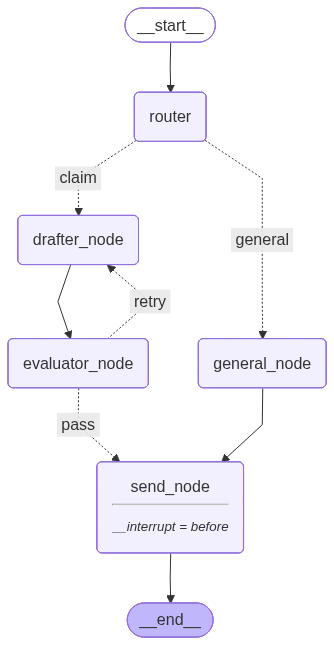

In [5]:
app

## 7. 실전 통합 테스트
엄청나게 화난 고객의 메시지가 들어왔다고 가정해봅시다.

In [6]:
customer_claim = "아니 어제 산 배추가 다 썩어문드러져서 왔잖아요!!! 당장 환불해줘요 진짜 장사 이딴 식으로 할겁니까?"
config = {"configurable": {"thread_id": "cs-ticket-1004"}}

print("===============================================")
print("🚨 [CS 센터 알림] 신규 고객 문의 접수됨")
print(f"내용: {customer_claim}")
print("===============================================\n")

# 파이프라인 가동 (send 직전까지 자동 진행됨)
for event in app.stream({"customer_msg": customer_claim}, config):
    pass

current_state = app.get_state(config)
print("\n===============================================")
print("⚠️ [CS 관리자 대시보드] 발송 대기 중인 초안")
print("===============================================")
print(current_state.values["draft_response"])
print("\n>> 담당자님, 해당 사과문을 이대로 고객에게 발송(Approve)하시겠습니까? (대기 중...)")

🚨 [CS 센터 알림] 신규 고객 문의 접수됨
내용: 아니 어제 산 배추가 다 썩어문드러져서 왔잖아요!!! 당장 환불해줘요 진짜 장사 이딴 식으로 할겁니까?


🔍 [Router] 고객 문의를 분석합니다...
-> 분류 결과: CLAIM

✍️ [Claim Drafter] (재)사과문 초안 작성 중...

🧐 [Claim Evaluator] 사과문 품질 및 어조 검사 중...
-> [평가 통과] 변명 없는 깔끔한 사과문입니다.

⚠️ [CS 관리자 대시보드] 발송 대기 중인 초안
고객님, 불편을 드린 점 진심으로 죄송합니다. 배추에 대한 문제로 실망을 안겨드린 점 사과드리며, 즉시 환불 처리를 진행하겠습니다. 앞으로 더 나은 품질을 제공할 수 있도록 최선을 다하겠습니다.

>> 담당자님, 해당 사과문을 이대로 고객에게 발송(Approve)하시겠습니까? (대기 중...)


## 8. 담당자 최종 승인 (발송)

In [7]:
print("\n[상담원이 Approve 버튼을 클릭했습니다.]")
for event in app.stream(None, config):
    pass
    
print("\n✅ CS 티켓 #1004 처리가 완료되었습니다.")


[상담원이 Approve 버튼을 클릭했습니다.]

🚀 [Send] (삐빅) 고객에게 최종 메시지가 발송되었습니다!!
최종 발송 내용: 고객님, 불편을 드린 점 진심으로 죄송합니다. 배추에 대한 문제로 실망을 안겨드린 점 사과드리며, 즉시 환불 처리를 진행하겠습니다. 앞으로 더 나은 품질을 제공할 수 있도록 최선을 다하겠습니다.

✅ CS 티켓 #1004 처리가 완료되었습니다.


## 9. 결론 및 회고

축하합니다! 🎉
1~7번 챕터를 거치며 프롬프트 튜닝, RAG, Tool Calling을 넘어, LangGraph를 활용한 **실제 기업용 AI 에이전트 파이프라인**까지 구축해 냈습니다.
단순히 챗봇이 아닌, **업무 프로세스 자체를 자동화하는 시스템(Agentic Workflow)**의 위력을 확인하셨기를 바랍니다!